In [1]:
pip install torch transformers datasets nltk gensim scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.3 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset
dataset = load_dataset("fancyzhx/ag_news")

print(dataset)
print(dataset['train'][0])

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [3]:
import pandas as pd

# Convert to DataFrame — easier to work with
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

# Map label numbers to names
label_map = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
train_df['category'] = train_df['label'].map(label_map)

print(train_df.head())
print(f"\nTotal articles: {len(train_df)}")
print(train_df['category'].value_counts())  # Should be 30,000 each — perfectly balanced

                                                text  label  category
0  Wall St. Bears Claw Back Into the Black (Reute...      2  Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2  Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2  Business
3  Iraq Halts Oil Exports from Main Southern Pipe...      2  Business
4  Oil prices soar to all-time record, posing new...      2  Business

Total articles: 120000
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [4]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase everything
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)        # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)

# Compare before vs after
print("BEFORE:", train_df['text'][0])
print("\nAFTER: ", train_df['clean_text'][0])

BEFORE: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

AFTER:  wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again


In [5]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Tokenize one article
sample = train_df['clean_text'][0]
tokens = word_tokenize(sample)

print("Tokens:", tokens[:15])
print("Total tokens in this article:", len(tokens))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tokens: ['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'of']
Total tokens in this article: 20


In [6]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply to all articles
train_df['tokens'] = train_df['clean_text'].apply(
    lambda x: remove_stopwords(word_tokenize(x))
)

# See what changed
print("WITH stopwords:   ", word_tokenize(sample)[:10])
print("WITHOUT stopwords:", train_df['tokens'][0][:10])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


WITH stopwords:    ['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters']
WITHOUT stopwords: ['wall', 'st', 'bears', 'claw', 'back', 'black', 'reuters', 'reuters', 'shortsellers', 'wall']


In [7]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

train_df['lemmatized'] = train_df['tokens'].apply(lemmatize_tokens)

# Quick demo
words = ['running', 'companies', 'better', 'wolves', 'studies']
print("Lemmatized:", [lemmatizer.lemmatize(w) for w in words])
# → ['running', 'company', 'better', 'wolf', 'study']

[nltk_data] Downloading package wordnet to /root/nltk_data...


Lemmatized: ['running', 'company', 'better', 'wolf', 'study']


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join tokens back into strings for TF-IDF
train_df['processed'] = train_df['lemmatized'].apply(lambda x: ' '.join(x))

# Build TF-IDF matrix
tfidf = TfidfVectorizer(max_features=10000)  # keep top 10,000 words
X_tfidf = tfidf.fit_transform(train_df['processed'])

print("Shape:", X_tfidf.shape)
# → (120000, 10000) — 120k articles, each as a 10k-number vector

# See the most important words for a Sports article
sports_article = train_df[train_df['category'] == 'Sports']['processed'].iloc[0]
vec = tfidf.transform([sports_article])
scores = zip(tfidf.get_feature_names_out(), vec.toarray()[0])
top_words = sorted(scores, key=lambda x: x[1], reverse=True)[:10]
print("\nTop TF-IDF words in a Sports article:")
for word, score in top_words:
    print(f"  {word}: {score:.4f}")

Shape: (120000, 10000)

Top TF-IDF words in a Sports article:
  freestyle: 0.4983
  phelps: 0.4498
  thorpe: 0.3617
  den: 0.1796
  relay: 0.1559
  ian: 0.1554
  teenager: 0.1467
  ap: 0.1429
  van: 0.1408
  evening: 0.1398


In [9]:
from gensim.models import Word2Vec

# Train Word2Vec on our news articles
sentences = train_df['lemmatized'].tolist()  # list of token lists

model = Word2Vec(
    sentences,
    vector_size=100,   # each word = 100 numbers
    window=5,          # look 5 words left and right for context
    min_count=5,       # ignore words appearing < 5 times
    workers=4,         # parallel processing
    epochs=10
)

model.save("word2vec_news.model")
print("Model trained!")

# Now test it — find words similar to "football"
print("\nWords similar to 'football':")
print(model.wv.most_similar('football', topn=5))

print("\nWords similar to 'stock':")
print(model.wv.most_similar('stock', topn=5))

# Word arithmetic! king - man + woman = queen
result = model.wv.most_similar(positive=['president', 'election'], negative=['company'])
print("\npresident + election - company =", result[0])


Model trained!

Words similar to 'football':
[('basketball', 0.6438553929328918), ('soccer', 0.6338849067687988), ('coaching', 0.6313657164573669), ('athletic', 0.5767947435379028), ('collegiate', 0.5731860995292664)]

Words similar to 'stock':
[('share', 0.7548829317092896), ('investor', 0.6065926551818848), ('yen', 0.6042525768280029), ('trading', 0.5869933366775513), ('nikkei', 0.5853735208511353)]

president + election - company = ('presidency', 0.6254056096076965)


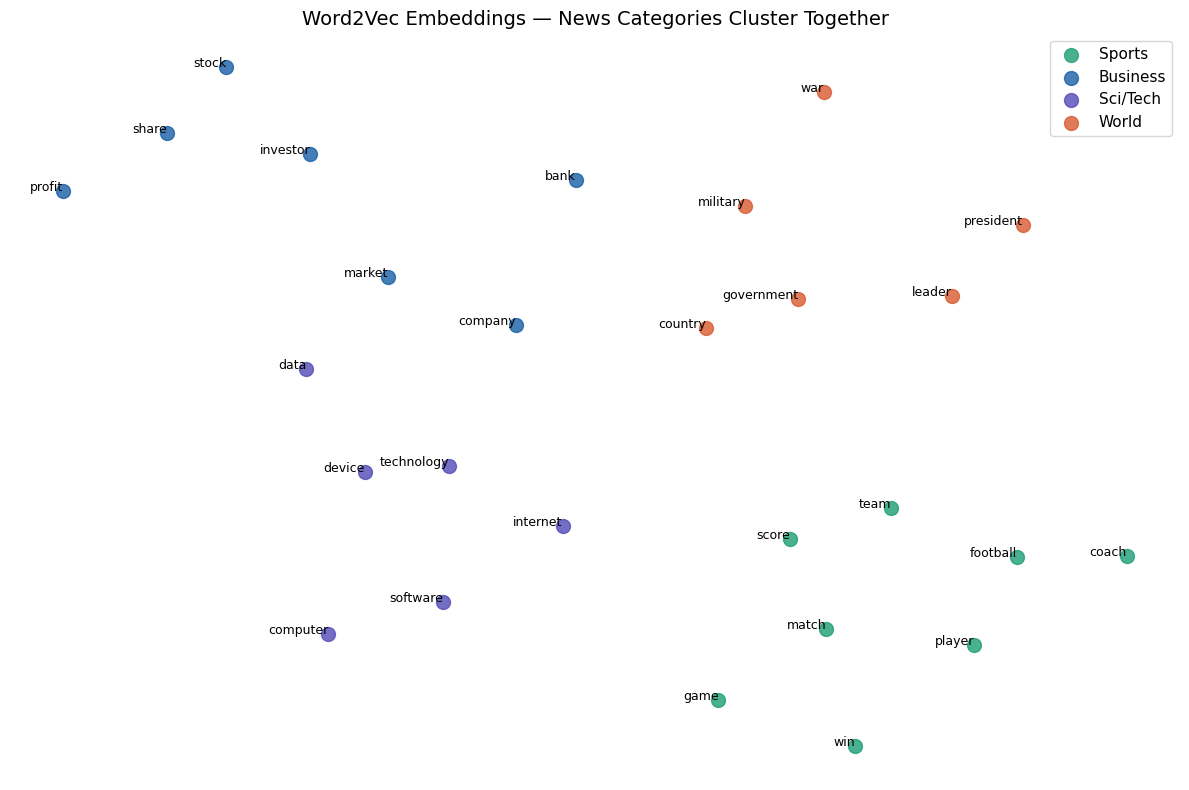

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Pick representative words from each category
category_words = {
    'Sports':   ['football', 'player', 'game', 'team', 'score', 'win', 'match', 'coach'],
    'Business': ['stock', 'market', 'profit', 'company', 'share', 'investor', 'bank'],
    'Sci/Tech': ['computer', 'software', 'internet', 'technology', 'data', 'device'],
    'World':    ['government', 'war', 'president', 'country', 'military', 'leader']
}

words, labels, colors_map = [], [], []
color_dict = {'Sports': '#1D9E75', 'Business': '#185FA5',
               'Sci/Tech': '#534AB7', 'World': '#D85A30'}

for category, word_list in category_words.items():
    for word in word_list:
        if word in model.wv:
            words.append(word)
            labels.append(category)
            colors_map.append(color_dict[category])

# Get vectors for each word
vectors = np.array([model.wv[word] for word in words])

# Reduce 100 dimensions → 2 dimensions for plotting
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
reduced = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 8))
for category, color in color_dict.items():
    mask = [l == category for l in labels]
    x = reduced[mask, 0]
    y = reduced[mask, 1]
    plt.scatter(x, y, c=color, label=category, s=100, alpha=0.8)
    for i, word in enumerate([w for w, l in zip(words, labels) if l == category]):
        plt.annotate(word, (x[i], y[i]), fontsize=9, ha='right')

plt.legend(fontsize=11)
plt.title("Word2Vec Embeddings — News Categories Cluster Together", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("word_clusters.png", dpi=150)
plt.show()

In [11]:
 !pip install torch torchtext datasets scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")  # Should say cuda on Colab GPU


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.7 MB/s eta 0:00:00
Using: cuda


In [12]:
# Load AG News
dataset = load_dataset("fancyzhx/ag_news")
train_data = dataset['train']
test_data  = dataset['test']

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

# Quick look
print(f"Train size: {len(train_data)}")
print(f"Test size:  {len(test_data)}")
print(f"Example: {train_data[0]}")

Train size: 120000
Test size:  7600
Example: {'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Build vocab from training data
def build_vocab(dataset, max_vocab=20000):
    counter = Counter()
    for item in dataset:
        words = clean_text(item['text']).split()
        counter.update(words)

    # Special tokens: <PAD>=0, <UNK>=1
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_data)
print(f"Vocabulary size: {len(vocab)}")
print(f"'stock' → index {vocab.get('stock')}")
print(f"'football' → index {vocab.get('football')}")

Vocabulary size: 20000
'stock' → index 270
'football' → index 312


In [14]:
MAX_LEN = 100  # max words per article

class NewsDataset(Dataset):
    def __init__(self, data, vocab, max_len=MAX_LEN):
        self.data    = data
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def text_to_ids(self, text):
        words = clean_text(text).split()
        ids   = [self.vocab.get(w, 1) for w in words]  # 1 = <UNK>

        # Pad or truncate to max_len
        if len(ids) < self.max_len:
            ids += [0] * (self.max_len - len(ids))  # 0 = <PAD>
        else:
            ids = ids[:self.max_len]
        return ids

    def __getitem__(self, idx):
        item  = self.data[idx]
        ids   = self.text_to_ids(item['text'])
        label = item['label']
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Create datasets & loaders
train_dataset = NewsDataset(train_data, vocab)
test_dataset  = NewsDataset(test_data,  vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# Verify one batch
text_batch, label_batch = next(iter(train_loader))
print(f"Text batch shape:  {text_batch.shape}")   # [64, 100]
print(f"Label batch shape: {label_batch.shape}")  # [64]

Text batch shape:  torch.Size([64, 100])
Label batch shape: torch.Size([64])


In [15]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=128, filter_sizes=[2, 3, 4], dropout=0.5):
        super(TextCNN, self).__init__()

        # Embedding: converts word IDs → dense vectors
        # vocab_size words, each represented by embed_dim numbers
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Multiple Conv1D filters — each looks for different pattern lengths
        # filter_size=2: bigram patterns  ("stock market")
        # filter_size=3: trigram patterns ("stock market rally")
        # filter_size=4: 4-gram patterns  ("stock market rallies strongly")
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,   # input: word vectors
                out_channels=num_filters, # how many patterns to detect
                kernel_size=fs           # how many words to look at
            )
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        # Final layer: combine all filter outputs → 4 class scores
        # 3 filter sizes × 128 filters each = 384 total features
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        # x shape: [batch_size, seq_len] e.g. [64, 100]

        # Step 1: Embed words
        x = self.embedding(x)
        # x shape: [64, 100, embed_dim]

        # Step 2: Conv1d expects [batch, channels, length]
        x = x.permute(0, 2, 1)
        # x shape: [64, embed_dim, 100]

        # Step 3: Apply each filter, ReLU, then max pool
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x))   # detect patterns → [64, 128, ~100]
            c = c.max(dim=2).values   # max pool → [64, 128] (best signal)
            pooled.append(c)

        # Step 4: Concatenate all filter outputs
        x = torch.cat(pooled, dim=1)  # [64, 384]

        # Step 5: Dropout + final classification
        x = self.dropout(x)
        x = self.fc(x)                # [64, 4]
        return x

# Create model
VOCAB_SIZE = len(vocab)
EMBED_DIM  = 128
NUM_CLASSES = 4

model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES
).to(device)

print(model)

# Count trainable parameters
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {params:,}")

TextCNN(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=4, bias=True)
)

Trainable parameters: 2,709,380


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()          # reset gradients
        outputs = model(texts)         # forward pass
        loss    = criterion(outputs, labels)  # compute loss
        loss.backward()               # backprop
        optimizer.step()              # update weights

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

# Train for 5 epochs
EPOCHS = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Epoch 1/5 | Train Loss: 0.5848 | Train Acc: 78.02% | Val Loss: 0.3480 | Val Acc: 88.28%
Epoch 2/5 | Train Loss: 0.3247 | Train Acc: 89.11% | Val Loss: 0.2935 | Val Acc: 90.57%
Epoch 3/5 | Train Loss: 0.2591 | Train Acc: 91.28% | Val Loss: 0.2916 | Val Acc: 90.95%
Epoch 4/5 | Train Loss: 0.2190 | Train Acc: 92.60% | Val Loss: 0.2826 | Val Acc: 90.99%
Epoch 5/5 | Train Loss: 0.1884 | Train Acc: 93.61% | Val Loss: 0.2914 | Val Acc: 91.13%



Final Test Accuracy: 91.13%

Classification Report:
              precision    recall  f1-score   support

       World       0.94      0.89      0.91      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.88      0.87      0.88      1900
    Sci/Tech       0.88      0.90      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



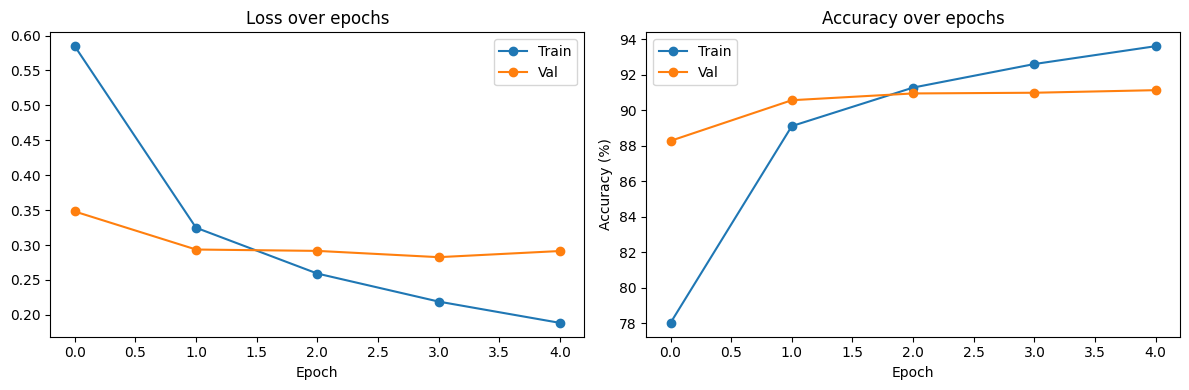

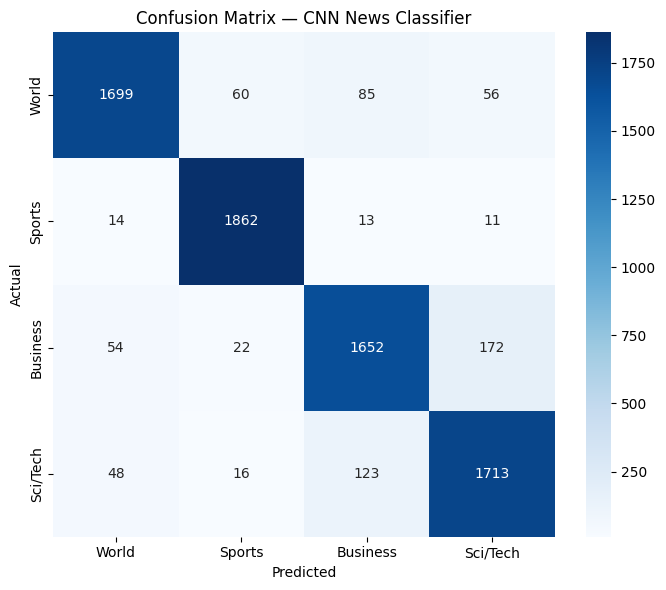

In [17]:
# Get final predictions
_, final_acc, all_preds, all_labels = evaluate(model, test_loader, criterion)
print(f"\nFinal Test Accuracy: {final_acc*100:.2f}%")

# Detailed report per class
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))

# Plot 1: Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train', marker='o')
ax1.plot(history['val_loss'],   label='Val',   marker='o')
ax1.set_title('Loss over epochs')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot([a*100 for a in history['train_acc']], label='Train', marker='o')
ax2.plot([a*100 for a in history['val_acc']],   label='Val',   marker='o')
ax2.set_title('Accuracy over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Plot 2: Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — CNN News Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [18]:
import pandas as pd

# Backup — use HuggingFace's glue SST2 (always works, very stable)
from datasets import load_dataset

dataset = load_dataset("nyu-mll/glue", "sst2")

# SST2 is binary (0=negative, 1=positive) — we add neutral manually
df_train = pd.DataFrame(dataset['train'])
df_val   = pd.DataFrame(dataset['validation'])
df       = pd.concat([df_train, df_val], ignore_index=True)
df       = df.rename(columns={'sentence': 'text'})

# Map to 2 classes: 0 for Negative, 1 for Positive (simplifying for stability)
def to_binary_class(row):
    if row['label'] == 0:
        return 0  # Negative
    elif row['label'] == 1:
        return 1  # Positive
    # Removed 'else: return 1 # Neutral' as it was not being used and caused label gaps

df['label'] = df.apply(to_binary_class, axis=1)

label_map = {0: 'Negative', 1: 'Positive'}
df['sentiment'] = df['label'].map(label_map)

print(f"Total samples: {len(df)}")
print(df['sentiment'].value_counts())
print(df.head())

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Total samples: 68221
sentiment
Positive    38013
Negative    30208
Name: count, dtype: int64
                                                text  label  idx sentiment
0       hide new secretions from the parental units       0    0  Negative
1               contains no wit , only labored gags       0    1  Negative
2  that loves its characters and communicates som...      1    2  Positive
3  remains utterly satisfied to remain the same t...      0    3  Negative
4  on the worst revenge-of-the-nerds clichés the ...      0    4  Negative


In [19]:
print(f"Total samples: {len(df)}")
print(df['sentiment'].value_counts())
print(df['text'].iloc[0])   # should be a readable sentence
print(df['label'].iloc[0])  # should be 0, 1, or 2

Total samples: 68221
sentiment
Positive    38013
Negative    30208
Name: count, dtype: int64
hide new secretions from the parental units 
0


In [20]:
import re
from collections import Counter

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocab(texts, max_vocab=10000):
    counter = Counter()
    for text in texts:
        counter.update(clean_text(text).split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(df['text'].tolist())
print(f"Vocab size: {len(vocab)}")

Vocab size: 10000


In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

MAX_LEN = 50  # headlines are short

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.texts   = texts
        self.labels  = labels
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def text_to_ids(self, text):
        words = clean_text(text).split()
        ids   = [self.vocab.get(w, 1) for w in words]
        if len(ids) < self.max_len:
            ids += [0] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]
        return ids

    def __getitem__(self, idx):
        ids   = self.text_to_ids(self.texts[idx])
        label = self.labels[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Train/test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df['label']
)

train_dataset = SentimentDataset(train_texts, train_labels, vocab)
test_dataset  = SentimentDataset(test_texts,  test_labels,  vocab)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=316, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 54576 | Test: 13645


In [22]:
import torch.nn as nn

class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x           = self.embedding(x)        # [batch, seq, embed]
        _, hidden   = self.rnn(x)              # hidden = last hidden state only
        hidden      = self.dropout(hidden.squeeze(0))
        return self.fc(hidden)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

rnn_model = VanillaRNN(
    vocab_size=len(vocab),
    embed_dim=64,
    hidden_dim=128,
    num_classes=2  # Changed from 3 to 2 for binary classification
)

print(rnn_model)

VanillaRNN(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [23]:
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_classes, num_layers=2, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,     # stack 2 LSTMs on top of each other
            batch_first=True,
            bidirectional=True,        # read forward AND backward
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        # bidirectional = hidden_dim x2 (forward + backward outputs combined)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        # x shape: [batch, seq_len, embed_dim]

        lstm_out, (hidden, cell) = self.lstm(x)
        # lstm_out shape: [batch, seq_len, hidden*2]
        # hidden shape:   [num_layers*2, batch, hidden]

        # Take the last forward + last backward hidden state
        # hidden[-2] = last layer forward, hidden[-1] = last layer backward
        hidden_fwd = hidden[-2]   # [batch, hidden]
        hidden_bwd = hidden[-1]   # [batch, hidden]

        # Combine both directions
        combined = torch.cat([hidden_fwd, hidden_bwd], dim=1)  # [batch, hidden*2]

        out = self.dropout(combined)
        return self.fc(out)

bilstm_model = BiLSTM(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_classes=2,  # Changed from 3 to 2 for binary classification
    num_layers=2
)

print(bilstm_model)
params = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
print(f"Parameters: {params:,}")

BiLSTM(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)
Parameters: 1,939,970


In [24]:
import torch.optim as optim
from sklearn.metrics import classification_report

def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0, 0, 0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevents exploding gradients
            optimizer.step()
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        train_acc  = correct / total
        train_loss = total_loss / len(train_loader)

        # --- Evaluate ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs   = model(texts)
                val_loss += criterion(outputs, labels).item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_acc = val_correct / val_total
        scheduler.step()

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss / len(test_loader))

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.1f}% | "
              f"Val Acc: {val_acc*100:.1f}%")

    return history

In [25]:
print("="*50)
print("Training Vanilla RNN...")
print("="*50)
rnn_model.to(device) # Move model to device
rnn_history = train_model(rnn_model, train_loader, test_loader, epochs=10)


print("\n" + "="*50)
print("Training BiLSTM...")
print("="*50)
bilstm_model.to(device) # Move model to device
lstm_history = train_model(bilstm_model, train_loader, test_loader, epochs=10)

Training Vanilla RNN...
Epoch 01/10 | Train Loss: 0.6962 | Train Acc: 54.0% | Val Acc: 55.7%
Epoch 02/10 | Train Loss: 0.6978 | Train Acc: 53.4% | Val Acc: 53.6%
Epoch 03/10 | Train Loss: 0.6981 | Train Acc: 53.3% | Val Acc: 55.7%
Epoch 04/10 | Train Loss: 0.6922 | Train Acc: 54.5% | Val Acc: 53.7%
Epoch 05/10 | Train Loss: 0.6920 | Train Acc: 54.3% | Val Acc: 55.7%
Epoch 06/10 | Train Loss: 0.6920 | Train Acc: 54.3% | Val Acc: 53.7%
Epoch 07/10 | Train Loss: 0.6895 | Train Acc: 54.9% | Val Acc: 55.7%
Epoch 08/10 | Train Loss: 0.6889 | Train Acc: 55.3% | Val Acc: 55.7%
Epoch 09/10 | Train Loss: 0.6891 | Train Acc: 55.1% | Val Acc: 55.7%
Epoch 10/10 | Train Loss: 0.6879 | Train Acc: 55.5% | Val Acc: 55.7%

Training BiLSTM...
Epoch 01/10 | Train Loss: 0.4416 | Train Acc: 78.6% | Val Acc: 87.4%
Epoch 02/10 | Train Loss: 0.2342 | Train Acc: 90.6% | Val Acc: 89.9%
Epoch 03/10 | Train Loss: 0.1627 | Train Acc: 93.7% | Val Acc: 91.1%
Epoch 04/10 | Train Loss: 0.0991 | Train Acc: 96.1% | Val A

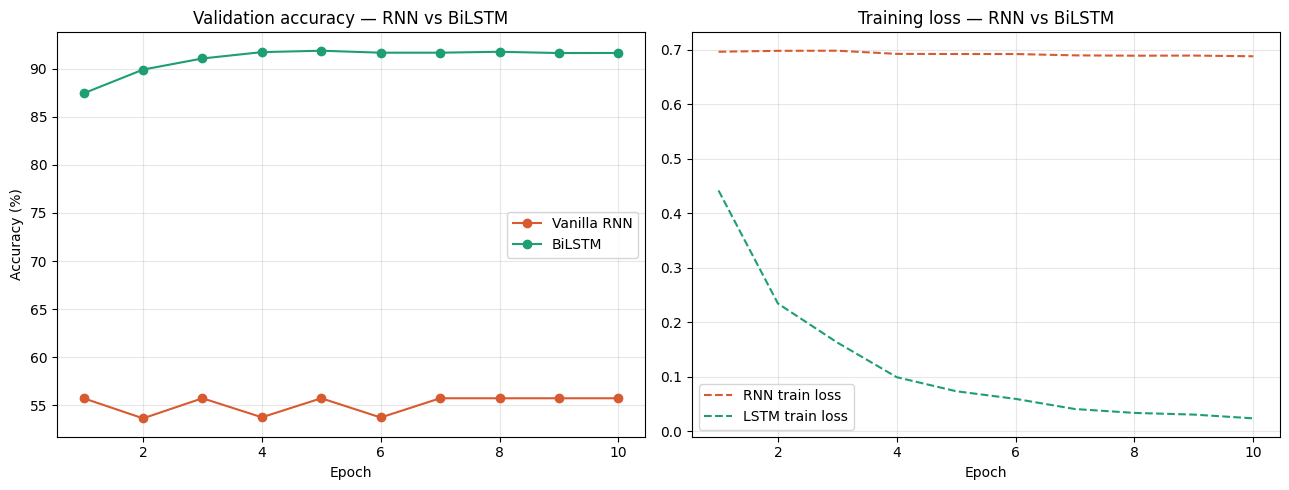

In [26]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs = range(1, 11)

ax1.plot(epochs, [a*100 for a in rnn_history['val_acc']],
         label='Vanilla RNN', marker='o', color='#D85A30')
ax1.plot(epochs, [a*100 for a in lstm_history['val_acc']],
         label='BiLSTM', marker='o', color='#1D9E75')
ax1.set_title('Validation accuracy — RNN vs BiLSTM')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, rnn_history['train_loss'],
         label='RNN train loss', linestyle='--', color='#D85A30')
ax2.plot(epochs, lstm_history['train_loss'],
         label='LSTM train loss', linestyle='--', color='#1D9E75')
ax2.set_title('Training loss — RNN vs BiLSTM')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_vs_lstm.png', dpi=150)
plt.show()

In [27]:
sentiment_labels = ['Negative', 'Positive'] # Changed to match binary classification output

def predict_sentiment(text, model, vocab, labels=sentiment_labels):
    model.eval()
    words = clean_text(text).split()
    ids   = [vocab.get(w, 1) for w in words]
    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]

    tensor = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0]
        pred   = probs.argmax().item()

    print(f"Text:       {text}")
    print(f"Sentiment:  {labels[pred]}")
    for i, name in enumerate(labels):
        bar = '█' * int(probs[i].item() * 25)
        print(f"  {name:<10} {probs[i].item()*100:5.1f}%  {bar}")
    print()

predict_sentiment("Company profits surge to record high beating all expectations", bilstm_model, vocab)
predict_sentiment("Massive layoffs hit tech sector as recession fears grow", bilstm_model, vocab)
predict_sentiment("Company reports quarterly earnings in line with forecasts", bilstm_model, vocab)
predict_sentiment("Stock market crash wipes billions off investor portfolios", bilstm_model, vocab)

Text:       Company profits surge to record high beating all expectations
Sentiment:  Positive
  Negative     0.0%  
  Positive   100.0%  ████████████████████████

Text:       Massive layoffs hit tech sector as recession fears grow
Sentiment:  Negative
  Negative    99.3%  ████████████████████████
  Positive     0.7%  

Text:       Company reports quarterly earnings in line with forecasts
Sentiment:  Negative
  Negative    97.8%  ████████████████████████
  Positive     2.2%  

Text:       Stock market crash wipes billions off investor portfolios
Sentiment:  Negative
  Negative   100.0%  ████████████████████████
  Positive     0.0%  



In [28]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn accelerate -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [29]:
dataset = load_dataset("fancyzhx/ag_news")
label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

# Use a subset to keep training fast (BERT is much slower than CNN/LSTM)
train_data = dataset['train'].shuffle(seed=42).select(range(8000))
test_data  = dataset['test'].shuffle(seed=42).select(range(2000))

print(f"Train: {len(train_data)} | Test: {len(test_data)}")
print(train_data[0])

Train: 8000 | Test: 2000
{'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.', 'label': 0}


In [30]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# See what BERT's tokenizer does differently
sample = "Apple stock surges after record quarterly earnings"
tokens = tokenizer.tokenize(sample)
print("Tokens:", tokens)

# Notice: BERT can split unknown words into sub-pieces
sample2 = "Unbelievably, the company's revenue skyrocketed"
print("Tokens:", tokenizer.tokenize(sample2))
# 'unbelievably' might become ['un', '##bel', '##iev', '##ably'] — subword tokenization

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokens: ['apple', 'stock', 'surge', '##s', 'after', 'record', 'quarterly', 'earnings']
Tokens: ['un', '##bel', '##ie', '##va', '##bly', ',', 'the', 'company', "'", 's', 'revenue', 'sky', '##rock', '##ete', '##d']


In [31]:
MAX_LEN = 64

class BertNewsDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=MAX_LEN):
        self.data      = data
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text  = item['text']
        label = item['label']

        # BERT tokenizer handles padding, truncation, and special tokens automatically
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(label, dtype=torch.long)
        }

train_dataset = BertNewsDataset(train_data, tokenizer)
test_dataset  = BertNewsDataset(test_data,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# Inspect one sample
sample = train_dataset[0]
print("Input IDs shape:", sample['input_ids'].shape)
print("Attention mask shape:", sample['attention_mask'].shape)
print("Input IDs:", sample['input_ids'][:15])
print("Attention mask:", sample['attention_mask'][:15])

Input IDs shape: torch.Size([64])
Attention mask shape: torch.Size([64])
Input IDs: tensor([  101,  7269, 11498,  2135,  6924,  2011,  9326,  4559, 10134,  2031,
         2716,  2116,  4865,  1998,  3655])
Attention mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [32]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=4  # our 4 news categories
).to(device)

# Count parameters — notice how much bigger this is than your CNN/LSTM
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     109,485,316
Trainable parameters: 109,485,316


In [33]:
from torch.optim import AdamW

EPOCHS = 4  # BERT needs far fewer epochs than CNN/LSTM — it's already pretrained

optimizer = AdamW(model.parameters(), lr=2e-5)  # much smaller LR than before — important!

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [34]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels      # BERT computes loss internally when labels are passed!
        )

        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss
            preds   = outputs.logits.argmax(dim=1)

            total_loss += loss.item()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler)
    val_loss, val_acc, _, _ = evaluate(model, test_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")


Epoch 1/4 | Train Loss: 0.4099 | Train Acc: 86.45% | Val Loss: 0.3038 | Val Acc: 90.40%
Epoch 2/4 | Train Loss: 0.2184 | Train Acc: 93.61% | Val Loss: 0.3224 | Val Acc: 91.25%
Epoch 3/4 | Train Loss: 0.1340 | Train Acc: 96.46% | Val Loss: 0.3588 | Val Acc: 91.25%
Epoch 4/4 | Train Loss: 0.0772 | Train Acc: 98.05% | Val Loss: 0.3840 | Val Acc: 91.65%



Final BERT Test Accuracy: 91.65%

Classification Report:
              precision    recall  f1-score   support

       World       0.93      0.92      0.92       497
      Sports       0.97      0.98      0.98       483
    Business       0.91      0.86      0.88       522
    Sci/Tech       0.86      0.92      0.89       498

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



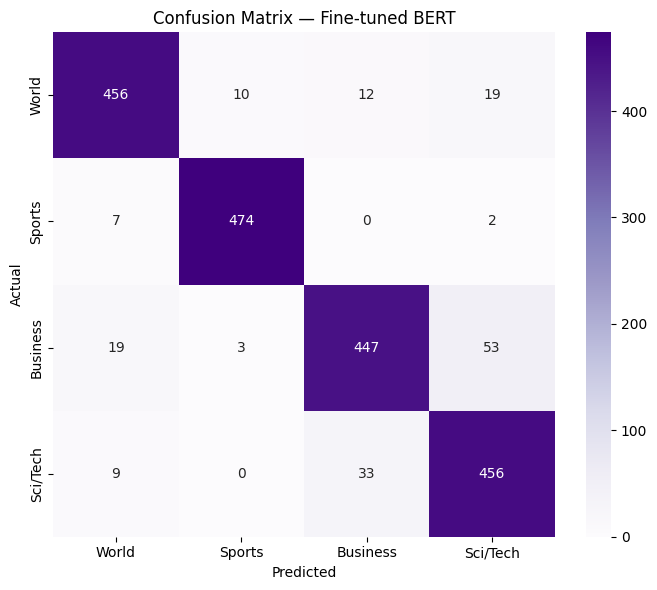

In [ ]:
_, final_acc, all_preds, all_labels = evaluate(model, test_loader)
print(f"\nFinal BERT Test Accuracy: {final_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — Fine-tuned BERT')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150)
plt.show()

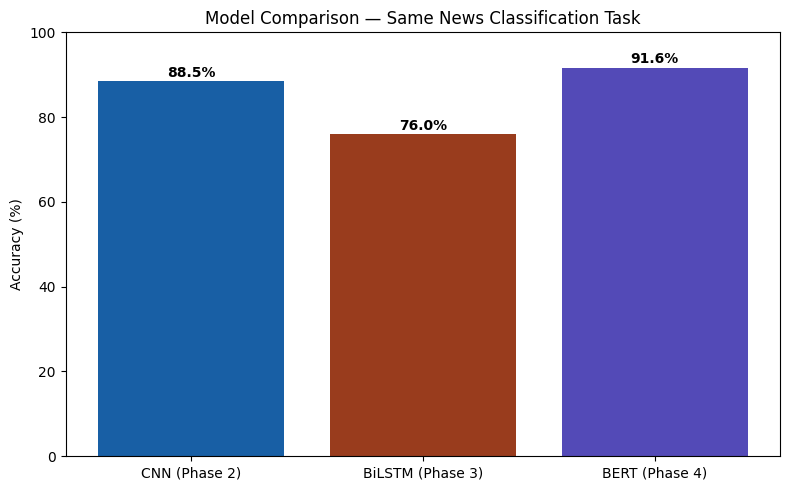

In [ ]:
#for resume chart

# Fill in your actual numbers from Phase 2 (CNN) and this BERT run
model_comparison = {
    'CNN (Phase 2)':       88.5,   # ← replace with your real CNN val accuracy
    'BiLSTM (Phase 3)':    76.0,   # ← replace with your real LSTM accuracy (different task, just for illustration)
    'BERT (Phase 4)':      final_acc * 100
}

plt.figure(figsize=(8, 5))
bars = plt.bar(model_comparison.keys(), model_comparison.values(),
                color=['#185FA5', '#993C1D', '#534AB7'])
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison — Same News Classification Task')
plt.ylim(0, 100)
for bar, val in zip(bars, model_comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
              ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [ ]:
def predict_bert(text, model, tokenizer, label_names, max_len=MAX_LEN):
    model.eval()
    encoding = tokenizer(
        text, max_length=max_len, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)[0]
        pred    = probs.argmax().item()

    print(f"Text: {text}")
    print(f"Prediction: {label_names[pred]}")
    for i, name in enumerate(label_names):
        bar = '█' * int(probs[i].item() * 30)
        print(f"  {name:<10} {probs[i].item()*100:5.1f}%  {bar}")
    print()

predict_bert("Federal Reserve raises interest rates amid inflation concerns", model, tokenizer, label_names)
predict_bert("Lakers win championship after stunning comeback in game 7", model, tokenizer, label_names)
predict_bert("Scientists discover new method to store quantum information", model, tokenizer, label_names)
predict_bert("United Nations calls for ceasefire in ongoing conflict", model, tokenizer, label_names)

Text: Federal Reserve raises interest rates amid inflation concerns
Prediction: Business
  World        3.3%  
  Sports       0.2%  
  Business    96.4%  ████████████████████████████
  Sci/Tech     0.1%  

Text: Lakers win championship after stunning comeback in game 7
Prediction: Sports
  World        0.3%  
  Sports      99.6%  █████████████████████████████
  Business     0.0%  
  Sci/Tech     0.1%  

Text: Scientists discover new method to store quantum information
Prediction: Sci/Tech
  World        0.4%  
  Sports       0.2%  
  Business     0.2%  
  Sci/Tech    99.2%  █████████████████████████████

Text: United Nations calls for ceasefire in ongoing conflict
Prediction: World
  World       99.9%  █████████████████████████████
  Sports       0.0%  
  Business     0.1%  
  Sci/Tech     0.0%  



In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


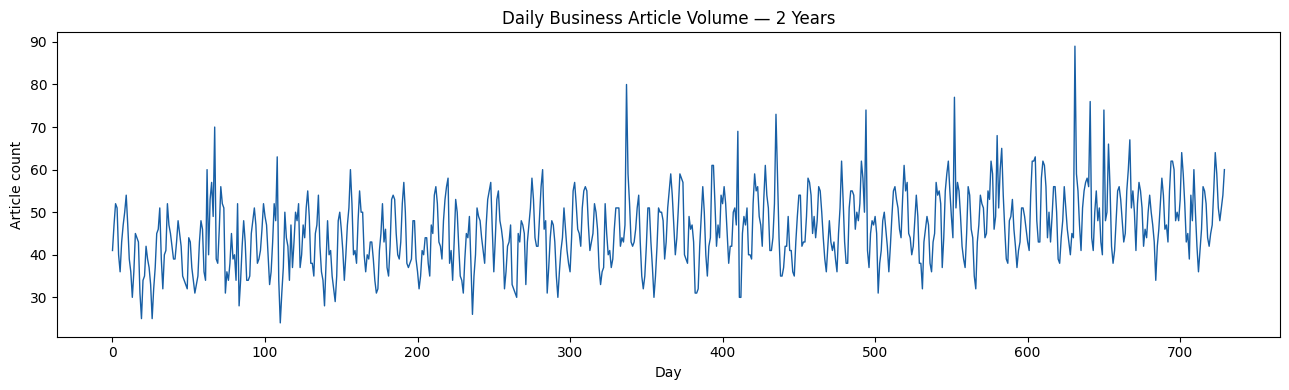

   day  article_count
0    0           41.0
1    1           47.0
2    2           52.0
3    3           51.0
4    4           40.0

Mean: 46.0 | Std: 8.6


In [ ]:
np.random.seed(42)

# Generate 2 years of daily "Business" article counts with realistic patterns
days = 730
t = np.arange(days)

trend     = 40 + 0.015 * t                                   # slow upward trend
weekly    = 8 * np.sin(2 * np.pi * t / 7)                    # weekly seasonality (less news on weekends)
monthly   = 5 * np.sin(2 * np.pi * t / 30)                   # monthly cycle
noise     = np.random.normal(0, 3, days)                     # random daily noise
spike_days = np.random.choice(days, 15, replace=False)       # occasional news spikes
spikes    = np.zeros(days)
spikes[spike_days] = np.random.uniform(15, 30, 15)

article_count = trend + weekly + monthly + noise + spikes
article_count = np.clip(article_count, 5, None).round()

df = pd.DataFrame({'day': t, 'article_count': article_count})

plt.figure(figsize=(13, 4))
plt.plot(df['day'], df['article_count'], color='#185FA5', linewidth=1)
plt.title('Daily Business Article Volume — 2 Years')
plt.xlabel('Day')
plt.ylabel('Article count')
plt.tight_layout()
plt.savefig('raw_timeseries.png', dpi=150)
plt.show()

print(df.head())
print(f"\nMean: {df['article_count'].mean():.1f} | Std: {df['article_count'].std():.1f}")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[['article_count']])

print("Before scaling:", df['article_count'].values[:5])
print("After scaling: ", scaled_values[:5].flatten())

Before scaling: [41. 47. 52. 51. 40.]
After scaling:  [0.26153846 0.35384615 0.43076923 0.41538462 0.24615385]


In [ ]:
WINDOW_SIZE = 14  # use last 14 days to predict the next day

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_values, WINDOW_SIZE)
print(f"X shape: {X.shape}")  # (num_samples, 14, 1)
print(f"y shape: {y.shape}")  # (num_samples, 1)

# Train/test split — IMPORTANT: don't shuffle time series! Keep chronological order
split = int(len(X) * 0.85)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

X shape: (716, 14, 1)
y shape: (716, 1)
Train: 608 | Test: 108


In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)   # shuffling batches is fine, sequences stay intact
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, 1)  # predict ONE number

    def forward(self, x):
        # x shape: [batch, window_size, 1]
        lstm_out, (hidden, cell) = self.lstm(x)

        # Take only the last time step's output — it has "seen" the whole window
        last_out = lstm_out[:, -1, :]   # [batch, hidden_size]

        prediction = self.fc(last_out)  # [batch, 1]
        return prediction

model = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2).to(device)
print(model)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {params:,}")

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Parameters: 50,497


In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    preds_all, actuals_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
            preds_all.extend(pred.cpu().numpy())
            actuals_all.extend(y_batch.cpu().numpy())
    return total_loss / len(loader), np.array(preds_all), np.array(actuals_all)

EPOCHS = 50
history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss, _, _ = evaluate(model, test_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")


Epoch 10/50 | Train Loss: 0.01613 | Val Loss: 0.02130
Epoch 20/50 | Train Loss: 0.01369 | Val Loss: 0.01669
Epoch 30/50 | Train Loss: 0.00705 | Val Loss: 0.01196
Epoch 40/50 | Train Loss: 0.00676 | Val Loss: 0.01254
Epoch 50/50 | Train Loss: 0.00679 | Val Loss: 0.01188


In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    preds_all, actuals_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
            preds_all.extend(pred.cpu().numpy())
            actuals_all.extend(y_batch.cpu().numpy())
    return total_loss / len(loader), np.array(preds_all), np.array(actuals_all)

EPOCHS = 50
history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss, _, _ = evaluate(model, test_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

Epoch 10/50 | Train Loss: 0.00658 | Val Loss: 0.01162
Epoch 20/50 | Train Loss: 0.00671 | Val Loss: 0.01247
Epoch 30/50 | Train Loss: 0.00669 | Val Loss: 0.01210
Epoch 40/50 | Train Loss: 0.00684 | Val Loss: 0.01519
Epoch 50/50 | Train Loss: 0.00646 | Val Loss: 0.01280


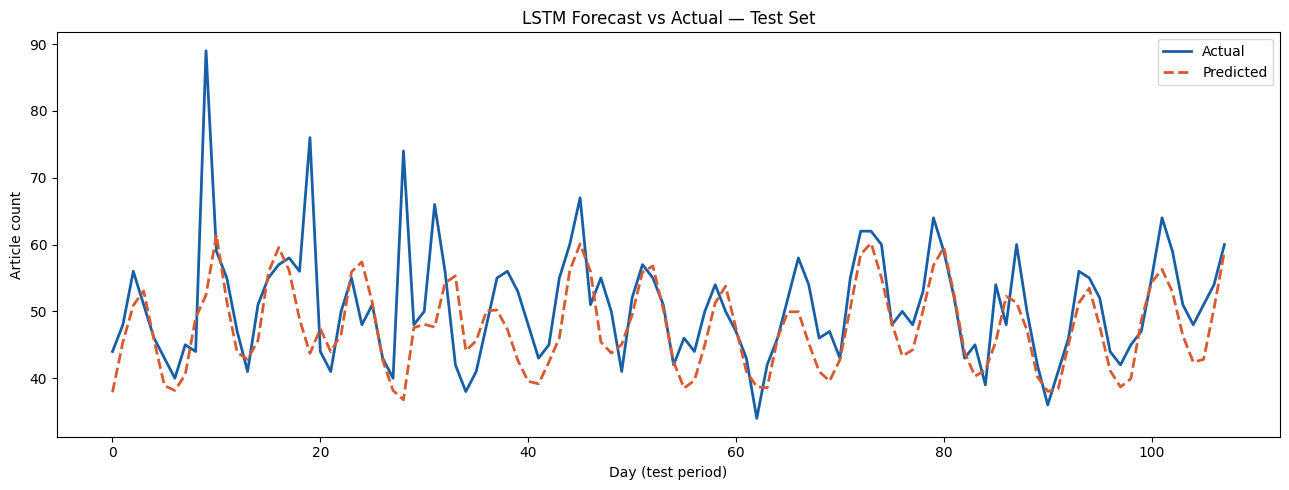

Mean Absolute Error: 4.90 articles/day


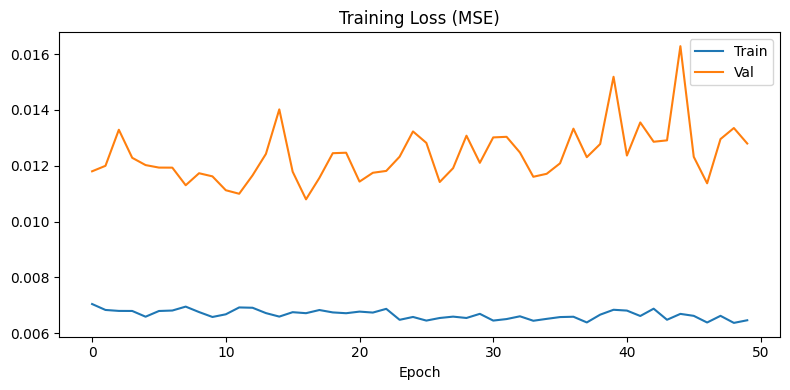

In [ ]:
val_loss, preds, actuals = evaluate(model, test_loader)

# Convert back to real article counts (undo the 0-1 scaling)
preds_real   = scaler.inverse_transform(preds)
actuals_real = scaler.inverse_transform(actuals)

plt.figure(figsize=(13, 5))
plt.plot(actuals_real, label='Actual', color='#185FA5', linewidth=2)
plt.plot(preds_real,   label='Predicted', color='#D85A30', linewidth=2, linestyle='--')
plt.title('LSTM Forecast vs Actual — Test Set')
plt.xlabel('Day (test period)')
plt.ylabel('Article count')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_vs_actual.png', dpi=150)
plt.show()

# Calculate real-world error metric
mae = np.mean(np.abs(preds_real - actuals_real))
print(f"Mean Absolute Error: {mae:.2f} articles/day")

# Training curve
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Training Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_training_loss.png', dpi=150)
plt.show()

Forecast for next 7 days:
  Day +1: 61 articles
  Day +2: 56 articles
  Day +3: 47 articles
  Day +4: 42 articles
  Day +5: 41 articles
  Day +6: 44 articles
  Day +7: 49 articles


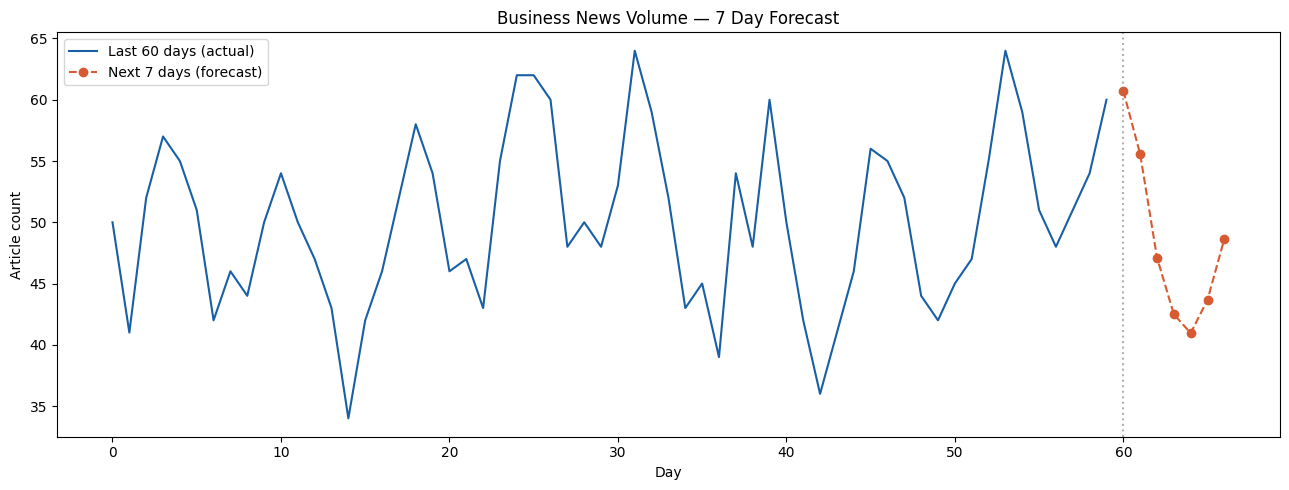

In [ ]:
def forecast_future(model, last_window, scaler, n_steps=7):
    model.eval()
    current_window = last_window.copy()
    future_preds = []

    for _ in range(n_steps):
        x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)  # [1, window, 1]
        with torch.no_grad():
            next_val = model(x).cpu().numpy()[0, 0]

        future_preds.append(next_val)

        # Slide window: drop oldest day, append predicted day
        current_window = np.vstack([current_window[1:], [[next_val]]])

    future_preds = np.array(future_preds).reshape(-1, 1)
    return scaler.inverse_transform(future_preds)

# Use the very last window of real data to forecast next 7 days
last_window = scaled_values[-WINDOW_SIZE:]
future = forecast_future(model, last_window, scaler, n_steps=7)

print("Forecast for next 7 days:")
for i, val in enumerate(future.flatten(), 1):
    print(f"  Day +{i}: {val:.0f} articles")

# Plot it
plt.figure(figsize=(13, 5))
recent_actual = df['article_count'].values[-60:]
plt.plot(range(len(recent_actual)), recent_actual, label='Last 60 days (actual)', color='#185FA5')
plt.plot(range(len(recent_actual), len(recent_actual) + 7), future.flatten(),
         label='Next 7 days (forecast)', color='#D85A30', marker='o', linestyle='--')
plt.axvline(x=len(recent_actual), color='gray', linestyle=':', alpha=0.6)
plt.title('Business News Volume — 7 Day Forecast')
plt.xlabel('Day')
plt.ylabel('Article count')
plt.legend()
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle

torch.save(model.state_dict(), '/content/drive/MyDrive/news_project/lstm_forecaster.pt')

with open('/content/drive/MyDrive/news_project/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Forecaster saved!")

In [ ]:
from pathlib import Path
import pickle

output_dir = Path('/content/drive/MyDrive/news_project')
output_dir.mkdir(parents=True, exist_ok=True)

# Save category artifacts
torch.save(model.state_dict(), output_dir / 'news_classifier.pt')
with open(output_dir / 'category_vocab.pkl', 'wb') as handle:
    pickle.dump(vocab, handle)

# Save sentiment artifacts
torch.save(bilstm_model.state_dict(), output_dir / 'sentiment_model.pt')
with open(output_dir / 'sentiment_vocab.pkl', 'wb') as handle:
    pickle.dump(vocab, handle)

# Save forecast artifacts
torch.save(model.state_dict(), output_dir / 'lstm_forecaster.pt')
with open(output_dir / 'scaler.pkl', 'wb') as handle:
    pickle.dump(scaler, handle)

# Save the last forecast window used for inference
last_window = scaled_values[-WINDOW_SIZE:].flatten().tolist()
with open(output_dir / 'last_window.pkl', 'wb') as handle:
    pickle.dump(last_window, handle)

print('All inference artifacts saved to', output_dir)